In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [2]:
import idna #implementacion de tecnicas de codificacion de strings (codificacion y decodificacion de caracterers unicode)

# def utf8_to_punycode(text: str) -> str:
#     """Encodes a UTF-8 string to its Punycode representation."""
#     return idna.encode(text).decode('ascii')

def punyencode(text: str) -> str:
    """Encodes a UTF-8 string to its Punycode representation, handling spaces by encoding each word separately."""
    
    return " ".join([idna.encode(word).decode('ascii') for word in text.split()])
    
def punydecode(punycode: str) -> str:
    """Decodes a Punycode string back to UTF-8."""
    #return idna.decode(punycode)
    return " ".join([idna.decode(word) for word in punycode.split()])

def process_name(name):
    name = name.lower()
    for n in name.split():
        if len(n) < 2:
            return ''
    try:
        return punyencode(name)
    except:
        #print(f'Cant convert {name}')
        return ''

dataset = open("city_names_full.txt", 'r', encoding='utf-8').read().split('\n')
with open('city_names_puny.txt', 'w', encoding='utf-8') as f:
    for n in dataset:
        name = process_name(n)
        if name != '':
            f.write(name + '\n')
dataset = open('city_names_puny.txt', 'r', encoding='utf-8').read().split('\n')
puny = [x for x in dataset if 'xn--' in x] #filtrar todos los que tienen caracteres raros
nopuny = [x for x in dataset if 'xn--' not in x]
np.random.seed(42)
dataset = [x.item() for x in np.random.choice(nopuny, 100000, replace=False)]

In [3]:
charset = ['*'] + sorted(list(set([y for x in dataset for y in x])))
ctoi = {c:i for i, c in enumerate(charset)}
itoc = {i:c for i, c in enumerate(charset)}
charset_size = len(charset)

In [4]:
class Model:
    def __init__(self, charset_size, context_size, emb_size, hidden_size, g=torch.Generator().manual_seed(42)):
        self.charset_size = charset_size
        self.context_size = context_size
        self.emb_size = emb_size
        self.hidden_size = hidden_size
        self.C = torch.randn(self.charset_size, self.emb_size, generator=g)
        self.W1 = torch.randn(self.emb_size*self.context_size, self.hidden_size, generator=g) * (5/3 / (self.emb_size*self.context_size)**0.5) #inicializacion kaiming
        self.b1 = torch.randn(self.hidden_size, generator=g) #no garantiza que no mueran capaz durante el entrenamiento, solo la init
        self.W2 = torch.randn(self.hidden_size, self.charset_size, generator=g)
        self.b2 = torch.randn(self.charset_size, generator=g)
        self.parameters = [self.C, self.W1, self.b1, self.W2, self.b2]
        for p in self.parameters:
            p.requires_grad = True
    
    def __call__(self, x):
        self.emb = self.C[x]
        self.embcat = self.emb.view(-1, self.emb_size*self.context_size)
        self.preact = self.embcat @ self.W1 + self.b1
        self.act = torch.tanh(self.preact)
        self.logits = self.act @ self.W2 + self.b2
        return self.logits

    def count_parameters(self):
        return sum([p.nelement() for p in self.parameters])

    def zero_grad(self):
        for p in self.parameters:
            p.grad = None

    def requieres_grad(self):
        for p in self.parameters:
            p.requieres_grad = True
 
    def sample(self, nsamples, g=torch.Generator().manual_seed(42)):
        samples = []
        for n in range(nsamples):
            context = [0] * context_size
            out = []
            while True:
                logits = self(torch.tensor(context))
                probs = F.softmax(logits, dim=1)
                idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
                context = context[1:] + [idx]
                out.append(itoc[idx])
                if idx == 0:
                    samples.append(''.join(out[:-1]))
                    break
        return samples

def nll(logits, Y):
    return F.cross_entropy(logits, Y)

In [5]:
def build_dataset(dataset: list):
    X, Y  = [], []
    for d in dataset:
        example = list(d) + ['*']
        context = [0] * context_size
        for c in example:
            X.append(context)
            Y.append(ctoi[c])
            context = context[1:] + [ctoi[c]] 
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

# build the dataset
context_size = 3
np.random.seed(42)
np.random.shuffle(dataset)
n1 = int(.8 * len(dataset))  # límite para el 80% del dataset
n2 = int(.9 * len(dataset))  # límite para el 90% del dataset
Xtr, Ytr = build_dataset(dataset[:n1])    # 80%
Xva, Yva = build_dataset(dataset[n1:n2])  # 10%
Xte, Yte = build_dataset(dataset[n2:])    # 10%

In [6]:
emb_size = 10
n_hidden = 256
model = Model(charset_size, context_size, emb_size, n_hidden, torch.Generator().manual_seed(42))
model.count_parameters()

18616

In [7]:
batch_size = 32

steps = 200000
losses = []
for i in range(steps):
    # 1. Forwards pass
    idx = torch.randint(0, len(Xtr), (batch_size, ))
    logits = model(Xtr[idx])
    
    # 2. loss
    loss = nll(logits, Ytr[idx])
    losses.append(loss.item())
    
    # 3. zero grad
    for p in model.parameters:
        p.grad = None
    
    # 4. backward pass
    loss.backward()
    
    # 5. update
    lr = 0.1 if i < 100000 else 0.01 # learing rate decay
    for p in model.parameters:
        p.data -= p.grad * lr
    if i%10000 == 0:
        print(f'epoch {i}/{steps} loss: {loss.item():0.4f}')
    #break    
print(f'Train loss {nll(model(Xtr), Ytr).item()}')
print(f'Vtion loss {nll(model(Xva), Yva).item()}')

epoch 0/200000 loss: 33.0136
epoch 10000/200000 loss: 2.8929
epoch 20000/200000 loss: 2.6782
epoch 30000/200000 loss: 2.8732
epoch 40000/200000 loss: 2.6723


KeyboardInterrupt: 

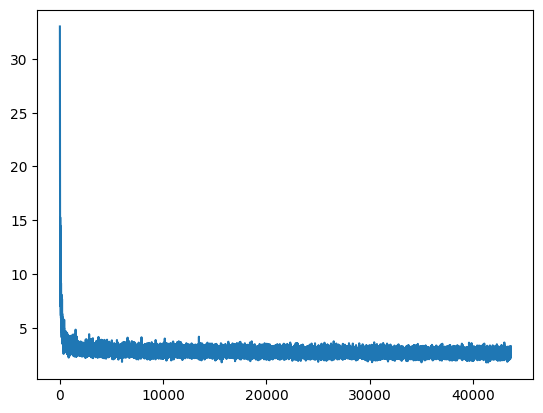

In [8]:
plt.plot(losses)

In [9]:
model.sample(10)

['latan-lasgat',
 'calahigianghama',
 'dobchau',
 'waghegowanghighadal pito',
 'pannbeughareyaua gattien',
 'undenghingahamoguaga',
 'hullahmachbagmagua',
 'mean',
 'nigolat',
 'drefpuan dlahi']

In [ ]:
#inicializacion de la red
#mayor lr = mas neuronas muertas

In [10]:
# Arreglando la saturación de la tanh con Kaiming Init

# De donde vienen esos números mágicos que multiplican a los pesos Ws y bs?

#pytorcheando

class Linear:
    def __init__ (self, input_dim, output_dim, bias=True, generator=torch.Generator().manual_seed(42)):
        self.W = torch.randn(input_dim, output_dim, generator=generator)/(input_dim**0.5)
        self.b = torch.zeros(output_dim) if bias else None
    
    def __call__(self,X):
        self.out = X @ self.W
        if self.b is not None:
            self.out += self.b
        return self.out
    
    def parameters(self):
        return [self.W] + ([] if self.b is None else [self.b])

class Tanh:
        def __call__(self, X):
             self.out = torch.tanh(X)
             return self.out
        
        def parameters(self):
             return[]
        
class Model:
    def __init__(self, charset_size, context_size, emb_size, hidden_size, g=torch.Generator().manual_seed(42)):
          self.charset_size = charset_size
          self.context_size = context_size
          self.emb_size = emb_size
          self.hidden_size = hidden_size
          self.C = torch.randn(self.charset_size, self.emb_size, generator = g)
          self.layers = [Linear(self.emb_size*self.context_size, self.hidden_size, generator=g), Tanh(),
                         Linear(self.hidden_size, self.hidden_size), Tanh(),
                         Linear(self.hidden_size, self.hidden_size), Tanh(),
                         Linear(self.hidden_size, self.hidden_size), Tanh(),
                         Linear(self.hidden_size, self.hidden_size), Tanh(),
                         Linear(self.hidden_size, self.charset_size)]
          for l in self.layers[:-1]:
                if isinstance(l, Linear):
                    l.W *= 5/3
                self.layers[-1].W*= 0.1 # La ultima capa es menos confianzuda
    
          for p in self.parameters():
                p.requires_grad = True
    
    def parameters(self):
        return [self.C] + [p for l in self.layers for p in l.parameters()]
    
    def __call__(self, X):
        self.emb = self.C[X]
        X = self.emb.view(-1, self.emb_size*self.context_size)
        for l in self.layers:
            X = l(X)
        return X
    
    def count_parameters(self):
         return sum([p.nelement() for p in self.parameters()])
    
    def to(self, device):
         for p in self.parameters():
              p.to(device)



In [11]:
emb_size = 10
n_hidden = 256
model = Model(charset_size, context_size, emb_size, n_hidden, torch.Generator().manual_seed(42))
model.count_parameters()

281784

In [13]:
model.to('cpu')

In [16]:
batch_size = 32
lr= 0.1
steps = 200000
losses = []
for i in range(steps):
    # 1. Forwards pass
    idx = torch.randint(0, len(Xtr), (batch_size, ))
    logits = model(Xtr[idx])
    
    # 2. loss
    loss = nll(logits, Ytr[idx])
    losses.append(loss.item())
    
    # 3. zero grad
    for p in model.parameters():
        p.grad = None
    
    # 4. backward pass
    loss.backward()
    
    # 5. update
    if i < 100000 and i< 200000: # learing rate decay
        lr= 0.1
    if i> 200000:
        lr= 0.1
    for p in model.parameters():
        p.data -= p.grad * lr
    if i%10000 == 0:
        print(f'epoch {i}/{steps} loss: {loss.item():0.4f}')
    #break    
print(f'Train loss {nll(model(Xtr), Ytr).item()}')
print(f'Vtion loss {nll(model(Xva), Yva).item()}')

epoch 0/200000 loss: 3.6889


KeyboardInterrupt: 